## CAD-Recode Demonstration
In this demonstration, we load a point cloud and process it using a pre-trained CAD-Recode model, which generates Python CadQuery code. Finally, we interpret the code to create a CAD model, visualize it, and evaluate its quality metrics. This notebook works on both CPU and GPU.

### Define CAD-Recode model

In [1]:
import open3d
import trimesh
import skimage.io
import numpy as np
import cadquery as cq
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import torch
from torch import nn
from transformers import (
    AutoTokenizer, Qwen2ForCausalLM, Qwen2Model, PreTrainedModel)
from transformers.modeling_outputs import CausalLMOutputWithPast
from pytorch3d.ops import sample_farthest_points
from pathlib import Path

class FourierPointEncoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        frequencies = 2.0 ** torch.arange(8, dtype=torch.float32)
        self.register_buffer('frequencies', frequencies, persistent=False)
        self.projection = nn.Linear(51, hidden_size)

    def forward(self, points):
        x = points
        x = (x.unsqueeze(-1) * self.frequencies).view(*x.shape[:-1], -1)
        x = torch.cat((points, x.sin(), x.cos()), dim=-1)
        x = self.projection(x)
        return x


class CADRecode(Qwen2ForCausalLM):
    def __init__(self, config):
        PreTrainedModel.__init__(self, config)
        self.model = Qwen2Model(config)
        self.vocab_size = config.vocab_size
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        
        torch.set_default_dtype(torch.float32)
        self.point_encoder = FourierPointEncoder(config.hidden_size)
        torch.set_default_dtype(torch.bfloat16)

    def forward(self,
                input_ids=None,
                attention_mask=None,
                point_cloud=None,
                position_ids=None,
                past_key_values=None,
                inputs_embeds=None,
                labels=None,
                use_cache=None,
                output_attentions=None,
                output_hidden_states=None,
                return_dict=None,
                cache_position=None):
        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # concatenate point and text embeddings
        if past_key_values is None or past_key_values.get_seq_length() == 0:
            assert inputs_embeds is None
            inputs_embeds = self.model.embed_tokens(input_ids)
            point_embeds = self.point_encoder(point_cloud).bfloat16()
            inputs_embeds[attention_mask == -1] = point_embeds.reshape(-1, point_embeds.shape[2])
            attention_mask[attention_mask == -1] = 1
            input_ids = None
            position_ids = None

        # decoder outputs consists of (dec_features, layer_state, dec_hidden, dec_attn)
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            inputs_embeds=inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            cache_position=cache_position)

        hidden_states = outputs[0]
        logits = self.lm_head(hidden_states)
        logits = logits.float()

        loss = None
        if labels is not None:
            # Shift so that tokens < n predict n
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            # Flatten the tokens
            loss_fct = nn.CrossEntropyLoss()
            shift_logits = shift_logits.view(-1, self.config.vocab_size)
            shift_labels = shift_labels.view(-1)
            # Enable model parallelism
            shift_labels = shift_labels.to(shift_logits.device)
            loss = loss_fct(shift_logits, shift_labels)

        if not return_dict:
            output = (logits,) + outputs[1:]
            return (loss,) + output if loss is not None else output

        return CausalLMOutputWithPast(
            loss=loss,
            logits=logits,
            past_key_values=outputs.past_key_values,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions)

    def prepare_inputs_for_generation(self, *args, **kwargs):
        model_inputs = super().prepare_inputs_for_generation(*args, **kwargs)
        model_inputs['point_cloud'] = kwargs['point_cloud']
        return model_inputs

### Load CAD-Recode checkpoint

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#attn_implementation = 'flash_attention_2' if torch.cuda.is_available() else None
tokenizer = AutoTokenizer.from_pretrained(
    'Qwen/Qwen2-1.5B',
    pad_token='<|im_end|>',
    padding_side='left')
#model = CADRecode.from_pretrained(
#    'filapro/cad-recode-v1.5',
#    torch_dtype='auto',
#    attn_implementation=attn_implementation).eval().to(device)
model = CADRecode.from_pretrained(
    'filapro/cad-recode-v1.5',
    torch_dtype='auto',
    attn_implementation=None).eval().to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

### Load input point cloud
Use output of MAPANYTHIN

In [37]:
# ================入力点群からCAD-RECODE用に256をサンプル
input_ply_org = "./data/car.ply"
input_ply = "./data/car_256.ply"
input_npy = "./data/car_256.npy"
output_stl = "./out/pred_car_256.stl"
# =====================================

In [38]:
# Sample 256Points
def farthest_point_sampling(points: np.ndarray, k: int) -> np.ndarray:
    n = len(points)
    if k >= n:
        return np.arange(n)
    selected = np.zeros(k, dtype=np.int64)
    center = points.mean(axis=0)
    dist_to_center = np.sum((points - center) ** 2, axis=1)
    selected[0] = np.argmax(dist_to_center)
    min_dist = np.sum((points - points[selected[0]]) ** 2, axis=1)
    for i in range(1, k):
        selected[i] = np.argmax(min_dist)
        new_dist = np.sum((points - points[selected[i]]) ** 2, axis=1)
        min_dist = np.minimum(min_dist, new_dist)
    return selected

In [39]:
input_path = Path(input_ply_org)
print(f"[INFO] loading: {input_path}")
pcd = open3d.io.read_point_cloud(str(input_path))
if pcd.is_empty():
    raise ValueError("Point cloud is empty")
points = np.asarray(pcd.points)
print(f"[INFO] total points: {len(points)}")
if len(points) < 256:
    raise ValueError("Need at least 256 points")
idx = farthest_point_sampling(points, 256)
sampled_pcd = open3d.geometry.PointCloud()
sampled_pcd.points = open3d.utility.Vector3dVector(points[idx])
if pcd.has_colors():
    colors = np.asarray(pcd.colors)
    sampled_pcd.colors = open3d.utility.Vector3dVector(colors[idx])
if pcd.has_normals():
    normals = np.asarray(pcd.normals)
    sampled_pcd.normals = open3d.utility.Vector3dVector(normals[idx])
print(f"[INFO] saving: {input_ply}")
open3d.io.write_point_cloud(input_ply, sampled_pcd, write_ascii=False)
print("[DONE]")


[INFO] loading: data/pot.ply
[INFO] total points: 30868
[INFO] saving: ./data/pot_256.ply
[DONE]


In [40]:
pcd = open3d.io.read_point_cloud(input_ply)
if pcd.is_empty():
    raise ValueError(f"Point cloud is empty: {input_ply}")
points = np.asarray(pcd.points, dtype=np.float32)
if points.shape[1] != 3:
    raise ValueError(f"Unexpected shape: {points.shape}")
np.save(input_npy, points)
print(f"Saved: {input_npy}")
print(f"shape: {points.shape}, dtype: {points.dtype}")

Saved: ./data/pot_256.npy
shape: (256, 3), dtype: float32


In [41]:
point_cloud = np.load(input_npy).astype(np.float32)
print(point_cloud.shape)
print(point_cloud.min(axis=0))
print(point_cloud.max(axis=0))

(256, 3)
[-0.07774353 -0.03796351 -0.01368672]
[0.13288116 0.06766152 0.29506326]


### Let's have a look at input point cloud
It looks like a table with four legs!

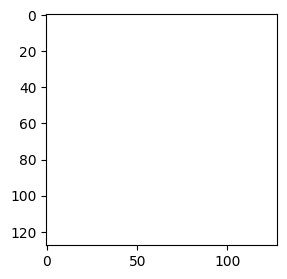

In [42]:
def render(geometry, image_size=128, camera_distance=-1.8, image_path='/tmp/tmp.png'):
    visualizer = open3d.visualization.Visualizer()
    visualizer.create_window(width=image_size * 4, height=image_size * 4)
    visualizer.add_geometry(geometry)

    lookat = np.array([0, 0, 0], dtype=np.float32)
    front = np.array([1, 1, 1], dtype=np.float32)
    up = np.array([0, 1, 0], dtype=np.float32)
    eye = lookat + front * camera_distance
    right = np.cross(up, front)
    right /= np.linalg.norm(right)
    true_up = np.cross(front, right)
    rotation_matrix = np.column_stack((right, true_up, front)).T
    extrinsic = np.eye(4)
    extrinsic[:3, :3] = rotation_matrix
    extrinsic[:3, 3] = -rotation_matrix @ eye

    view_control = visualizer.get_view_control()
    camera_params = view_control.convert_to_pinhole_camera_parameters()
    camera_params.extrinsic = extrinsic
    view_control.convert_from_pinhole_camera_parameters(camera_params)

    visualizer.poll_events()
    visualizer.update_renderer()
    visualizer.capture_screen_image(image_path)
    visualizer.destroy_window()

    image = skimage.io.imread(image_path)
    image = skimage.transform.resize(
        image,
        output_shape=(image_size, image_size),
        order=2,
        anti_aliasing=True,
        preserve_range=True).astype(np.uint8)
    return image

pcd = open3d.geometry.PointCloud()
pcd.points = open3d.utility.Vector3dVector(point_cloud)
pcd.paint_uniform_color(np.array([0, 80, 239]) / 255)
plt.figure(figsize=(3, 3))
_ = plt.imshow(render(pcd))

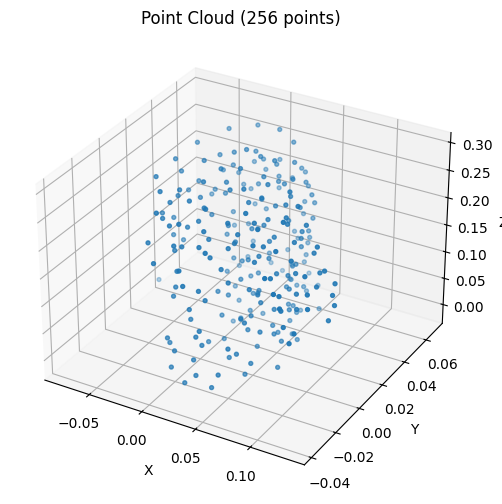

In [43]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    point_cloud[:, 0],
    point_cloud[:, 1],
    point_cloud[:, 2],
    s=8
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Point Cloud (256 points)")

plt.show()

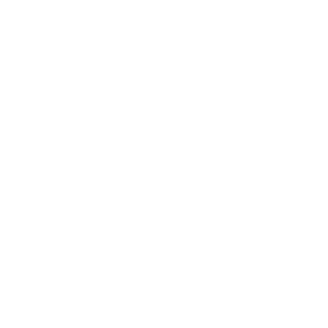

In [44]:
pcd = open3d.geometry.PointCloud()
pcd.points = open3d.utility.Vector3dVector(point_cloud)
pcd.paint_uniform_color(np.array([0, 80, 239]) / 255)

plt.figure(figsize=(4, 4))
_ = plt.imshow(render(pcd))
plt.axis("off")
plt.show()

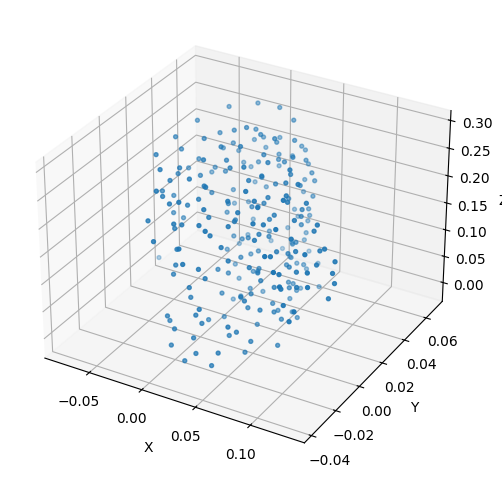

In [45]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(point_cloud[:, 0], point_cloud[:, 1], point_cloud[:, 2], s=8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

### Run CAD-Recode on the input point cloud

In [46]:
input_ids = [tokenizer.pad_token_id] * len(point_cloud) + [tokenizer('<|im_start|>')['input_ids'][0]]
attention_mask = [-1] * len(point_cloud) + [1]
with torch.no_grad():
    batch_ids = model.generate(
        input_ids=torch.tensor(input_ids).unsqueeze(0).to(model.device),
        attention_mask=torch.tensor(attention_mask).unsqueeze(0).to(model.device),
        point_cloud=torch.tensor(point_cloud.astype(np.float32)).unsqueeze(0).to(model.device),
        max_new_tokens=768,
        pad_token_id=tokenizer.pad_token_id)
py_string = tokenizer.batch_decode(batch_ids)[0]
begin = py_string.find('<|im_start|>') + 12
end = py_string.find('<|endoftext|>')
py_string = py_string[begin: end]
print(py_string)

import cadquery as cq
w0=cq.Workplane('ZX',origin=(0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',origin=(0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('ZX',origin=(0,0=cq.Workplane('YZ',origin=(0,0=cq.Workplane('ZX',o

### Execute predicted python code to raise a CAD model
The predicted code might be invalid or could potentially cause memory leaks in CadQuery, as described in this [issue](https://github.com/CadQuery/cadquery/issues/1665).  Therefore, it is recommended to run the next cell in a separate process with a timeout of, for example, 3 seconds.:
```
process = Process(target=..., args=...)
process.start()
process.join(3)

if process.is_alive():
    process.terminate()
    process.join()
```
But in this demo safety is omitted.

In [47]:
exec(py_string, globals())
compound = globals()['r'].val()
vertices, faces = compound.tessellate(0.001, 0.1)
mesh = trimesh.Trimesh([(v.x, v.y, v.z) for v in vertices], faces)
mesh.export(output_stl)
cq.exporters.export(compound, output_stl)

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (<string>, line 2)

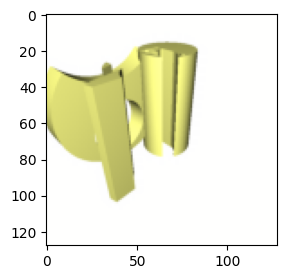

In [14]:
mesh = open3d.io.read_triangle_mesh(output_stl)
mesh.vertices = open3d.utility.Vector3dVector(np.asarray(mesh.vertices) / 100.)
mesh.paint_uniform_color(np.array([255, 255, 136]) / 255)
mesh.compute_vertex_normals()
plt.figure(figsize=(3, 3))
_ = plt.imshow(render(mesh))